# Diabetes Prediction using Machine Learning

This notebook demonstrates the process of building a machine learning model to predict diabetes using the Pima Indians Diabetes Database. It covers data loading, preprocessing, model training, and evaluation.

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose       

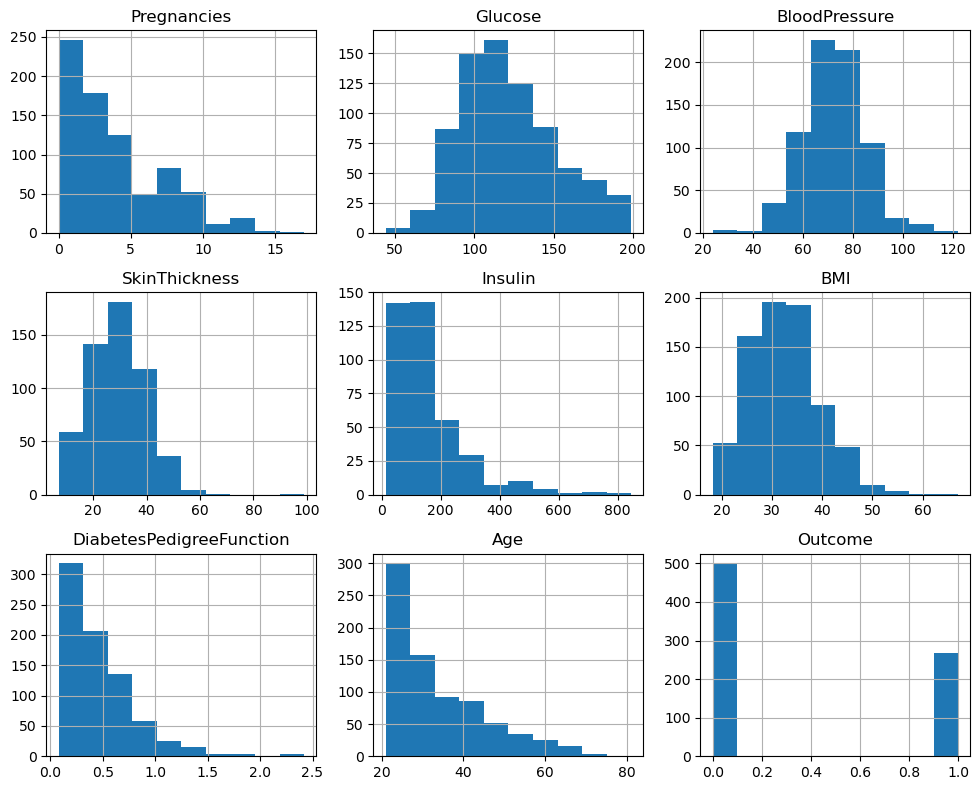

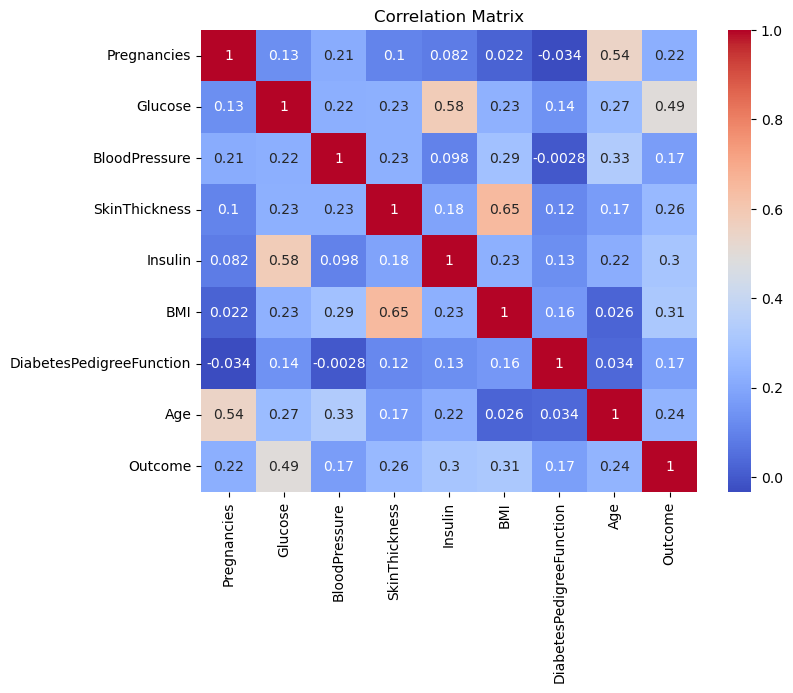

Starting tabular data preprocessing...
Tabular data preprocessing complete.

Shape of preprocessed features: (768, 8)
First 5 rows of preprocessed features:
   Pregnancies   Glucose  BloodPressure  SkinThickness       Insulin  \
0     0.639947  0.865108      -0.033518   6.655021e-01 -3.345079e-16   
1    -0.844885 -1.206162      -0.529859  -1.746338e-02 -3.345079e-16   
2     1.233880  2.015813      -0.695306   8.087936e-16 -3.345079e-16   
3    -0.844885 -1.074652      -0.529859  -7.004289e-01 -7.243887e-01   
4    -1.141852  0.503458      -2.680669   6.655021e-01  1.465506e-01   

        BMI  DiabetesPedigreeFunction       Age  
0  0.166292                  0.468492  1.425995  
1 -0.852531                 -0.365061 -0.190672  
2 -1.332833                  0.604397 -0.105584  
3 -0.634212                 -0.920763 -1.041549  
4  1.548980                  5.484909 -0.020496  
Data split into training and testing sets.
Training features shape: (614, 8)
Testing features shape: (154, 8)


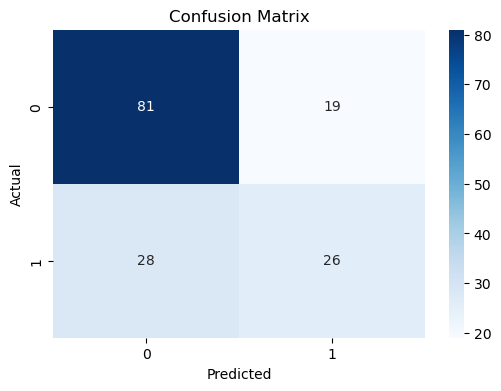

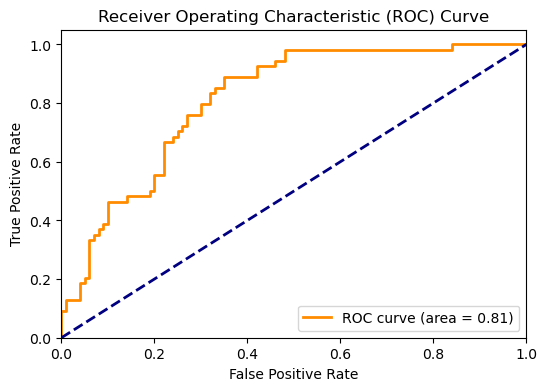

Model and preprocessor saved.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tarfile
import shutil
# Import data_preprocessing utility (assuming it"s in the same directory or accessible via PYTHONPATH)
# Adjust this to point to your project's root directory
sys.path.append(os.path.abspath('../'))

from src.utils.data_preprocessing import preprocess_tabular_data

# --- 1. Data Loading ---
# Ensure you have downloaded the Pima Indians Diabetes Dataset and placed it in the correct path.
# Download from: https://archive.ics.uci.edu/dataset/34/diabetes
# Save it as diabetes.csv in a "data/raw/" directory relative to your notebook.

# Path to your uploaded file

import pandas as pd
try:
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    column_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", 
                    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
    
    data = pd.read_csv(url, names=column_names)
    print(data.head())
except:
    print("The dataset is not found!!!")
# --- 2. Exploratory Data Analysis (EDA) ---
print("\nDataset Info:")
data.info()

print("\nDataset Description:")
data.describe()

print("\nMissing values (0s in certain columns are treated as missing):")
# For Pima Indians dataset, 0s in Glucose, BloodPressure, SkinThickness, Insulin, BMI are often missing values
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_cols:
    data[col] = data[col].replace(0, np.nan)

# Visualize distribution of features
data.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

# Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# --- 3. Data Preprocessing ---
# Define columns for preprocessing
numerical_cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
categorical_cols = [] # Pima dataset is typically all numerical, but if any were categorical, they"d go here
target_column = "Outcome"

# Replace 0s with NaN for proper imputation in specific columns
for col in zero_cols:
    data[col] = data[col].replace(0, np.nan)

X_processed, y, preprocessor = preprocess_tabular_data(
    df=data,
    numerical_cols=numerical_cols,
    categorical_cols=categorical_cols,  # keep empty list `[]` if none
    target_column='Outcome'
)


print("\nShape of preprocessed features:", X_processed.shape)
print("First 5 rows of preprocessed features:")
print(X_processed.head())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print("Data split into training and testing sets.")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

# --- 4. Model Building (Logistic Regression) ---
model = LogisticRegression(random_state=42, solver="liblinear")

print("Training Logistic Regression model...")
model.fit(X_train, y_train)
print("Model training complete.")

# --- 5. Model Evaluation ---
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\nModel Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")

# Classification Report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

# --- 6. Save Model (Optional) ---
import joblib
joblib.dump(model, "diabetes_logistic_regression_model.pkl")
joblib.dump(preprocessor, "diabetes_preprocessor.pkl")
print("Model and preprocessor saved.")
